In [1]:
import torch
import numpy as np
import pickle as pkl
from scipy import signal
import matplotlib.pyplot as plt

In [2]:
# getting a sample of all the datasets
spring_mass = pkl.load(open('../data/spring_mass/static_graph/graphs/trial_0.pkl', 'rb'))
dyn_spring_mass = pkl.load(open('../data/spring_mass/dynamic_graph/graphs/trial_0.pkl', 'rb'))
fish = pkl.load(open('../data/fish/processed/8fish/240816f1.pkl', 'rb'))

/projectnb/biochemai/Grant/interaction_rule_GNN/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# getting position, vel, and acc data
spring_mass_pos = torch.stack([i.pos for i in spring_mass])
spring_mass_vel = torch.stack([i.vel for i in spring_mass])
spring_mass_acc = torch.stack([i.acc for i in spring_mass])
spring_mass_pva = [spring_mass_pos, spring_mass_vel, spring_mass_acc]

dyn_spring_mass_pos = torch.stack([i.pos for i in dyn_spring_mass])
dyn_spring_mass_vel = torch.stack([i.vel for i in dyn_spring_mass])
dyn_spring_mass_acc = torch.stack([i.acc for i in dyn_spring_mass])
dyn_spring_mass_pva = [dyn_spring_mass_pos, dyn_spring_mass_vel, dyn_spring_mass_acc]

fish_pos = torch.stack([i.pos for i in fish])
fish_vel = torch.stack([i.vel for i in fish])
fish_acc = torch.stack([i.acc for i in fish])
fish_pva = [fish_pos, fish_vel, fish_acc]

In [4]:
def compute_autocorrelation(x, max_lag=None):
    """
    Compute autocorrelation function for a 1D time series.
    
    Parameters:
    -----------
    x : array-like, shape (time,)
        Time series data
    max_lag : int, optional
        Maximum lag to compute. If None, uses len(x)//2
    
    Returns:
    --------
    lags : array
        Lag values
    acf : array
        Autocorrelation values
    """
    x = np.asarray(x)
    x = x - np.mean(x)  # Remove mean
    
    if max_lag is None:
        max_lag = len(x) // 2
    
    # Use scipy's correlate function
    acf_full = signal.correlate(x, x, mode='full')
    acf_full = acf_full / acf_full[len(x)-1]  # Normalize by zero-lag
    
    # Take only positive lags
    acf = acf_full[len(x)-1:len(x)-1+max_lag]
    lags = np.arange(max_lag)
    
    return lags, acf

n_entities = 8
n_features = 2

# Compute autocorrelations
max_lag = 10000  # Adjust this based on your needs
feature_names = ['x', 'y']  # Or ['X', 'Y'], etc.

# Store all autocorrelations
acf_list = []

for data in spring_mass_pva:
    acfs = np.zeros((8, 2, max_lag))
    for entity in range(n_entities):
        for feature in range(n_features):
            lags, acf = compute_autocorrelation(data[:, entity, feature], max_lag=max_lag)
            acfs[entity, feature, :] = acf
    acf_list.append(acfs)

In [5]:
len(acf_list)

3

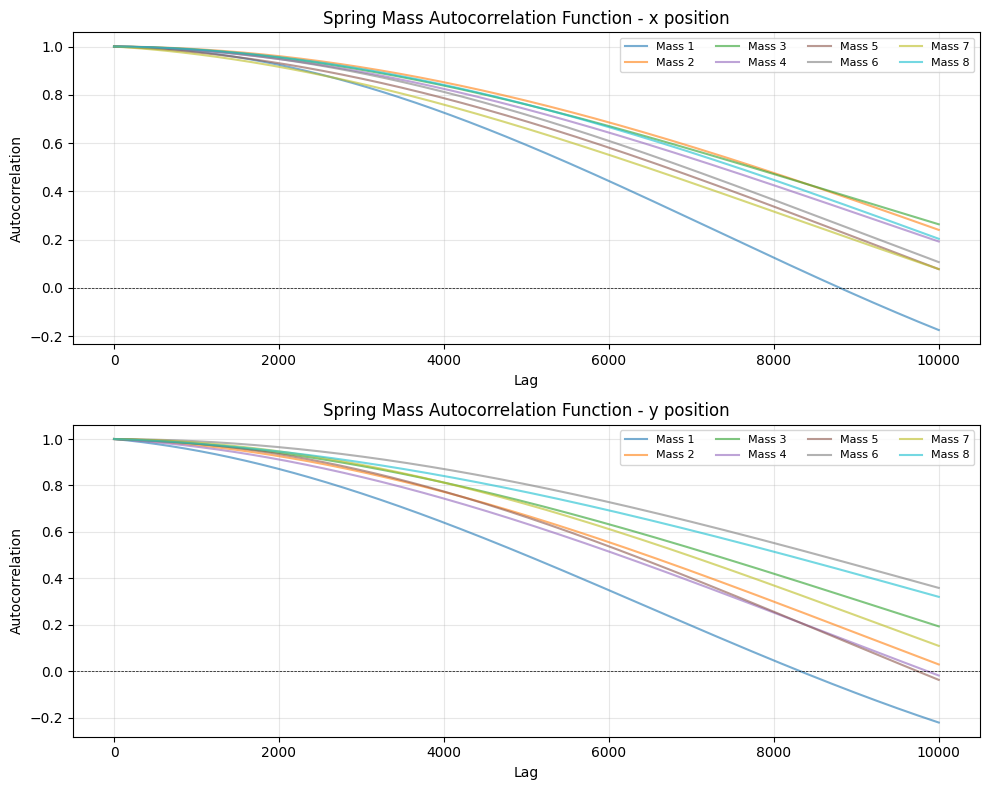

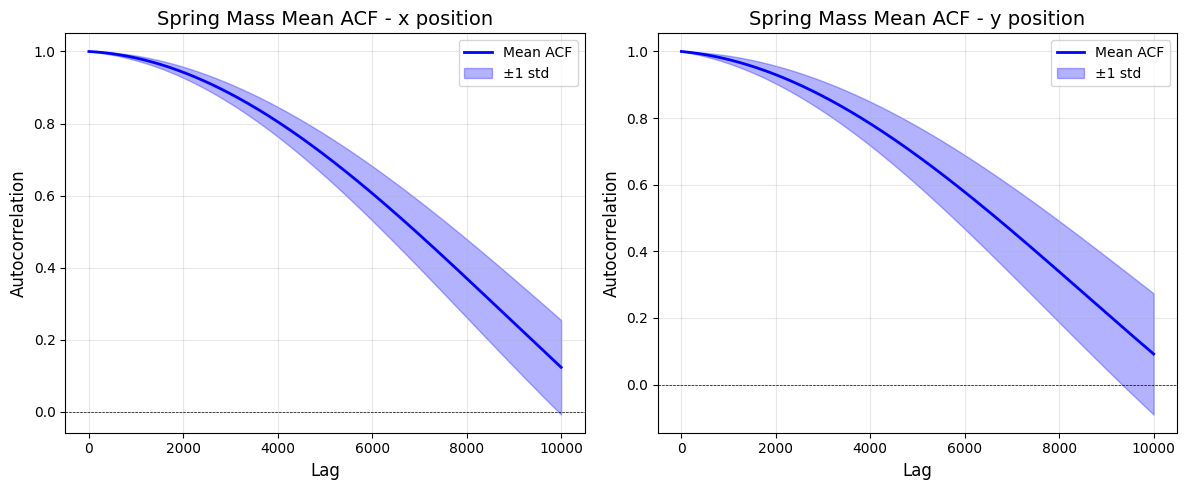

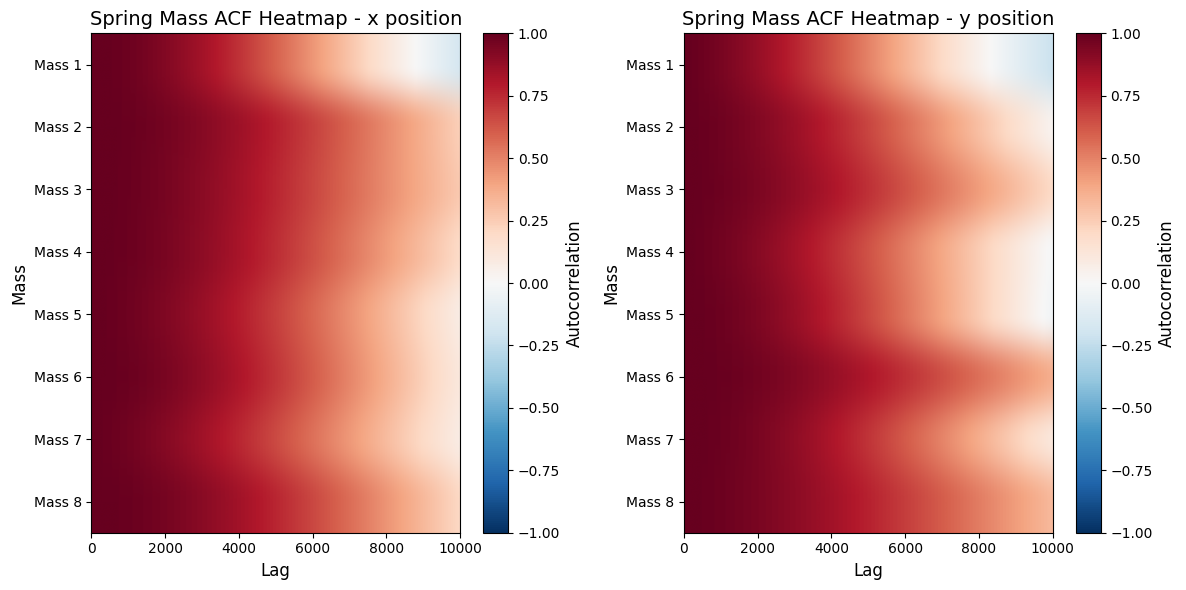

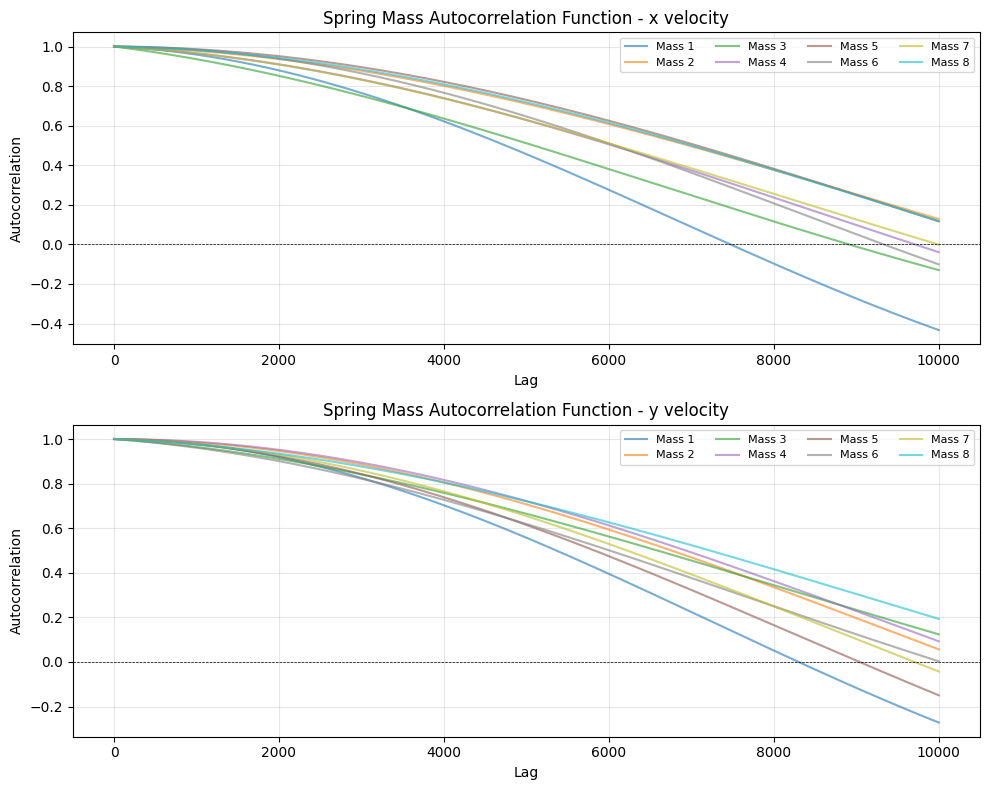

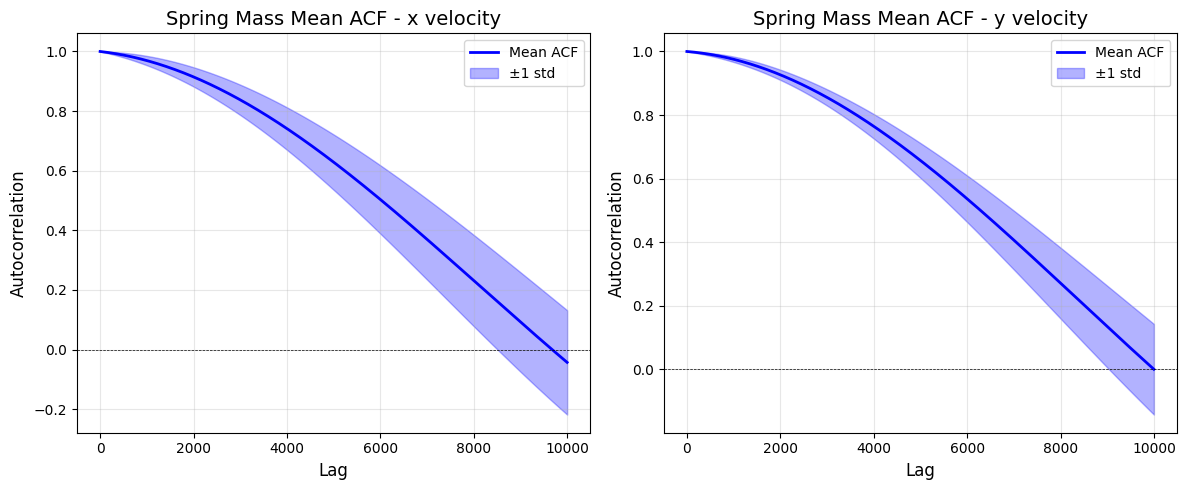

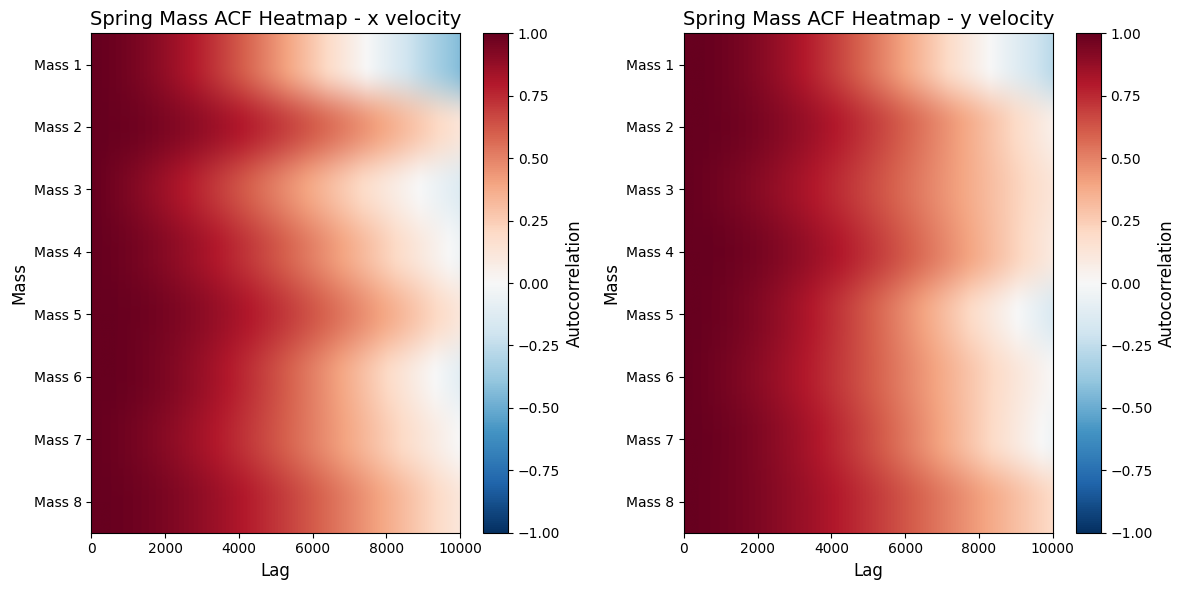

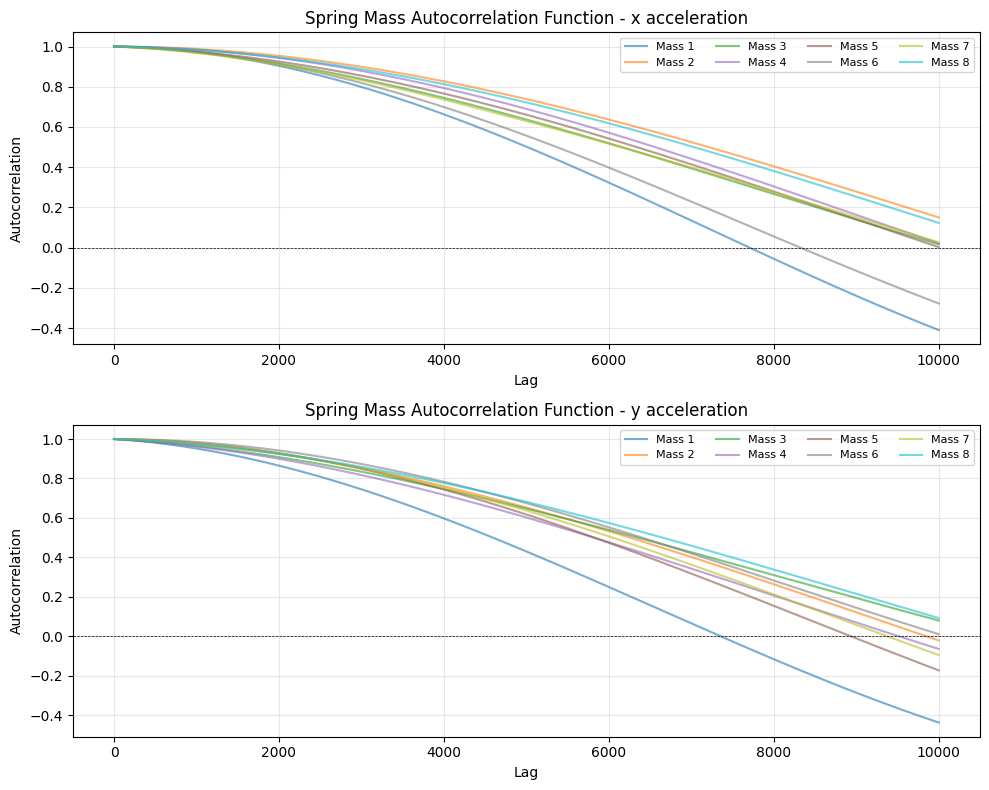

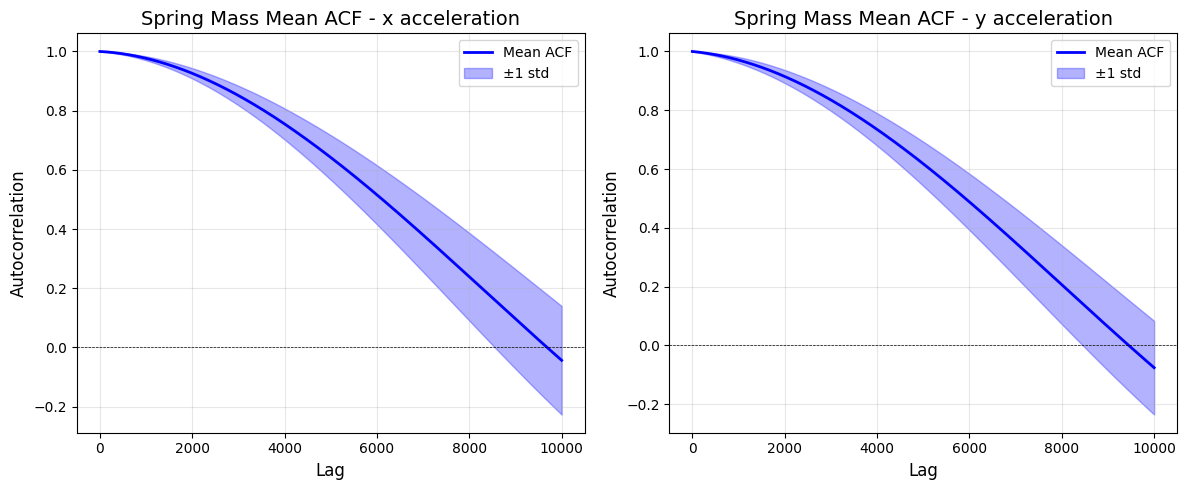

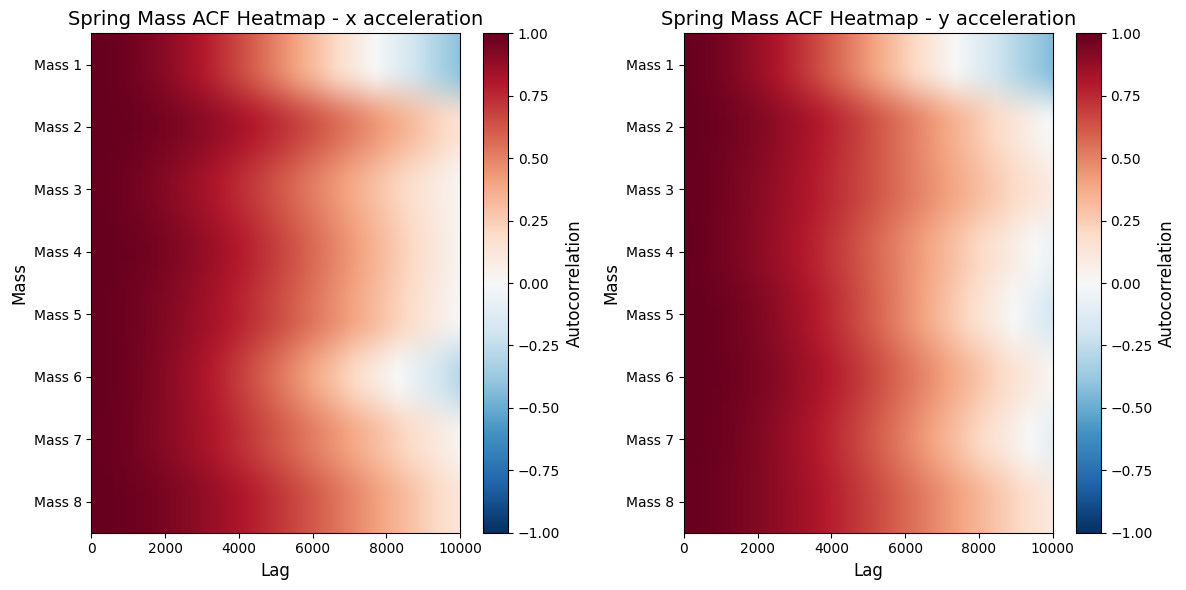

In [6]:
# ============================================================================
# PLOTTING
# ============================================================================

dataset_title = "Spring Mass"
thing_in_data = "Mass"

for (acfs, state_var) in zip(acf_list, ['position', 'velocity', 'acceleration']):
    # Plot 1: Individual autocorrelations for each entity and feature
    fig, axes = plt.subplots(n_features, 1, figsize=(10, 4*n_features))
    if n_features == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, n_entities))

    for feature in range(n_features):
        ax = axes[feature]
        
        for entity in range(n_entities):
            ax.plot(lags, acfs[entity, feature, :], 
                    alpha=0.6, linewidth=1.5, 
                    color=colors[entity],
                    label=f'{thing_in_data} {entity+1}')
        
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_xlabel('Lag')
        ax.set_ylabel('Autocorrelation')
        ax.set_title(f'{dataset_title} Autocorrelation Function - {feature_names[feature]} {state_var}')
        ax.legend(ncol=4, fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot 2: Mean autocorrelation across entities (with confidence bands)
    fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 5))
    if n_features == 1:
        axes = [axes]

    for feature in range(n_features):
        ax = axes[feature]
        
        # Calculate mean and std across entities
        mean_acf = np.mean(acfs[:, feature, :], axis=0)
        std_acf = np.std(acfs[:, feature, :], axis=0)
        
        # Plot mean with confidence band
        ax.plot(lags, mean_acf, linewidth=2, color='blue', label='Mean ACF')
        ax.fill_between(lags, 
                        mean_acf - std_acf, 
                        mean_acf + std_acf, 
                        alpha=0.3, color='blue', 
                        label='±1 std')
        
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_xlabel('Lag', fontsize=12)
        ax.set_ylabel('Autocorrelation', fontsize=12)
        ax.set_title(f'{dataset_title} Mean ACF - {feature_names[feature]} {state_var}', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot 3: Heatmap of autocorrelations
    fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 6))
    if n_features == 1:
        axes = [axes]

    for feature in range(n_features):
        ax = axes[feature]
        
        im = ax.imshow(acfs[:, feature, :], 
                    aspect='auto', 
                    cmap='RdBu_r', 
                    vmin=-1, vmax=1,
                    extent=[0, max_lag, n_entities-0.5, -0.5])
        
        ax.set_xlabel('Lag', fontsize=12)
        ax.set_ylabel(thing_in_data, fontsize=12)
        ax.set_title(f'{dataset_title} ACF Heatmap - {feature_names[feature]} {state_var}', fontsize=14)
        ax.set_yticks(range(n_entities))
        ax.set_yticklabels([f'{thing_in_data} {i+1}' for i in range(n_entities)])
        
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Autocorrelation', fontsize=12)

    plt.tight_layout()
    plt.show()

In [7]:
datasets.items

NameError: name 'datasets' is not defined

Spring Mass (static): suggested optimal dt = 167
Fish: suggested optimal dt = 7


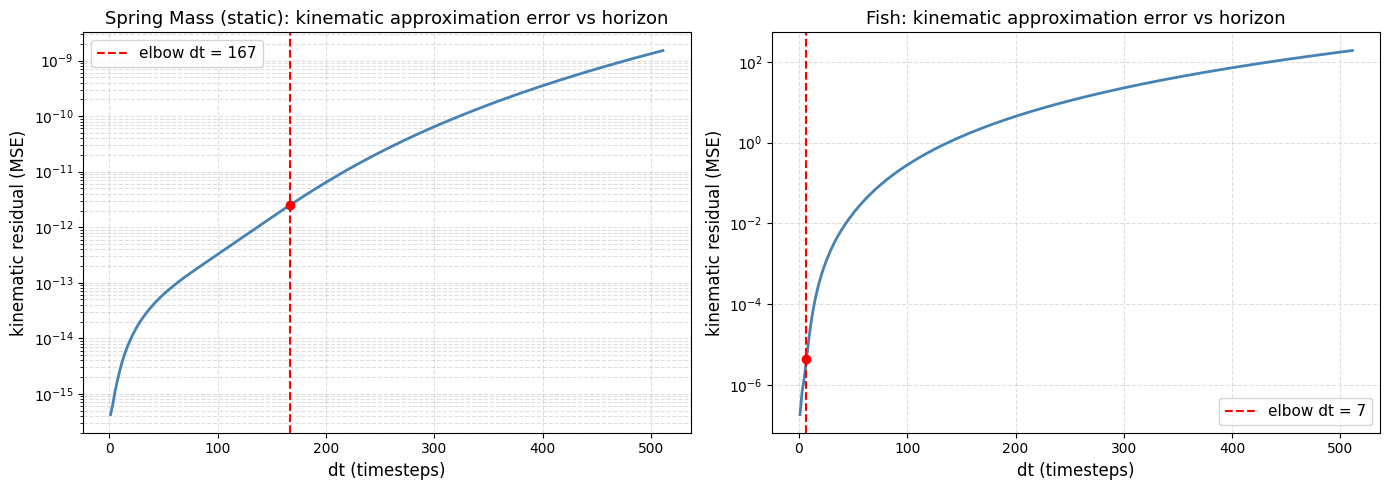

In [8]:
def kinematic_residual(data, max_dt_steps, stride=1, max_samples=2000):
    """
    For each horizon dt (in timesteps), compute the mean squared error of the
    constant-acceleration kinematic approximation:
        pos_kin(t+dt) = pos(t) + vel(t)*dt + 0.5*acc(t)*dt^2

    The optimal training horizon is the elbow of this curve — before this point
    the approximation holds, after it the higher-order terms dominate and the
    model can't learn a consistent acceleration target.
    """
    base_dt = data[0].dt
    dts = list(range(1, max_dt_steps, stride))
    errors = []

    # subsample timesteps for speed
    indices = np.linspace(0, len(data) - max_dt_steps - 1, max_samples, dtype=int)

    for dt_steps in dts:
        actual_dt = dt_steps * base_dt
        errs = []
        for i in indices:
            if i + dt_steps >= len(data):
                continue
            g = data[i]
            g_future = data[i + dt_steps]
            pos_kin = g.pos + g.vel * actual_dt + 0.5 * g.acc * actual_dt ** 2
            err = torch.mean((pos_kin - g_future.pos) ** 2).item()
            errs.append(err)
        errors.append(np.mean(errs))

    return dts, errors


def find_optimal_dt(dts, errors):
    """
    Finds the elbow of the kinematic residual curve as the point of maximum
    curvature on a log-log scale (peak of the second derivative).
    """
    log_dts = np.log(np.array(dts, dtype=float))
    log_errs = np.log(np.array(errors, dtype=float))
    d2 = np.gradient(np.gradient(log_errs, log_dts), log_dts)
    elbow_idx = np.argmax(d2)
    return dts[elbow_idx], errors[elbow_idx]


datasets = {
    'Spring Mass (static)': spring_mass,
    'Fish': fish,
}

fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, (name, dataset) in zip(axes, datasets.items()):
    dts, errors = kinematic_residual(dataset, max_dt_steps=512, stride=2, max_samples=2000)
    opt_dt, opt_err = find_optimal_dt(dts, errors)

    ax.plot(dts, errors, color='steelblue', linewidth=2)
    ax.axvline(opt_dt, color='red', linestyle='--', linewidth=1.5,
               label=f'elbow dt = {opt_dt}')
    ax.scatter([opt_dt], [opt_err], color='red', zorder=5)
    ax.set_xlabel('dt (timesteps)', fontsize=12)
    ax.set_ylabel('kinematic residual (MSE)', fontsize=12)
    ax.set_title(f'{name}: kinematic approximation error vs horizon', fontsize=13)
    ax.set_yscale('log')
    ax.legend(fontsize=11)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    print(f'{name}: suggested optimal dt = {opt_dt}')

plt.tight_layout()
plt.show()
